## Evaluate a model offline

-   Test the functionality of retrieving and downloading the model from the bucket.
-   Test the functionality of loading in the downloaded model.
-   Test the model's performance on a set of 6 test images.
-   Test the inference speed of the model.
-   Test the distribution of predicted classes.
-   Test the distribution of the sizes of detected objects.

Let’s start by loading our trained model and our test data.

In [31]:
import pytest
import os
import boto3
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from botocore.client import Config
import matplotlib.pyplot as plt
import shutil

# MinIO configuration
MINIO_ENDPOINT_URL = "http://129.114.27.202:30000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "miniopassword"
BUCKET_NAME = "mlflow"
OBJECT_KEY = "5/ccd4f18c17fa4979973f1de130bdd83a/artifacts/weights/best.pt"
LOCAL_MODEL_PATH = "/tmp/best.pt"

# Test image directory
TEST_IMAGES_DIR = "tests/test_images"
SAVE_RESULTS_DIR = "tests/results"

In [32]:
def create_s3_client():
    """Create and return S3 client for MinIO."""
    client = boto3.client(
        's3',
        endpoint_url=MINIO_ENDPOINT_URL,
        aws_access_key_id=MINIO_ACCESS_KEY,
        aws_secret_access_key=MINIO_SECRET_KEY,
        config=Config(signature_version='s3v4'),
        region_name='us-east-1'
    )
    return client


In [33]:
def download_model():
    """Download model from MinIO and return local path."""
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(LOCAL_MODEL_PATH), exist_ok=True)
    
    # Get S3 client
    s3_client = create_s3_client()
    
    # Check if model is already downloaded
    if not os.path.exists(LOCAL_MODEL_PATH):
        print(f"Downloading model from MinIO to {LOCAL_MODEL_PATH}...")
        s3_client.download_file(BUCKET_NAME, OBJECT_KEY, LOCAL_MODEL_PATH)
        print("Download complete.")
    else:
        print(f"Using existing model at {LOCAL_MODEL_PATH}")
    
    return LOCAL_MODEL_PATH

def load_model(model_path):
    """Load YOLO model from the downloaded weights."""
    model = YOLO(model_path)
    return model

In [34]:
def get_test_images():
    """Get list of test images."""
    test_images_path = Path(TEST_IMAGES_DIR)
    assert test_images_path.exists(), f"Test images directory {TEST_IMAGES_DIR} not found"
    
    # Get all image files
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png']:
        image_files.extend(list(test_images_path.glob(f'*{ext}')))
    
    assert len(image_files) > 0, f"No image files found in {TEST_IMAGES_DIR}"
    return image_files

def create_result_dir():
    """Create directory for test results."""
    result_dir = Path(SAVE_RESULTS_DIR)
    if result_dir.exists():
        shutil.rmtree(result_dir)
    result_dir.mkdir(parents=True, exist_ok=True)
    return result_dir

In [35]:
def test_model_download():
    """Test that model was downloaded successfully."""
    model_path = download_model()
    assert os.path.exists(model_path), f"Model file {model_path} does not exist"
    assert os.path.getsize(model_path) > 1000000, "Model file is too small, likely corrupted"
    return model_path

def test_model_loading(model_path):
    """Test that model loads correctly."""
    model = load_model(model_path)
    assert model is not None, "Failed to load model"
    assert hasattr(model, 'predict'), "Model does not have predict method"
    return model

# Execute these functions
model_path = test_model_download()
model = test_model_loading(model_path)
test_images = get_test_images()
result_dir = create_result_dir()

Using existing model at /tmp/best.pt



image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 1 person, 21 cars, 1 truck, 1 stop sign, 168.4ms
Speed: 13.9ms preprocess, 168.4ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)


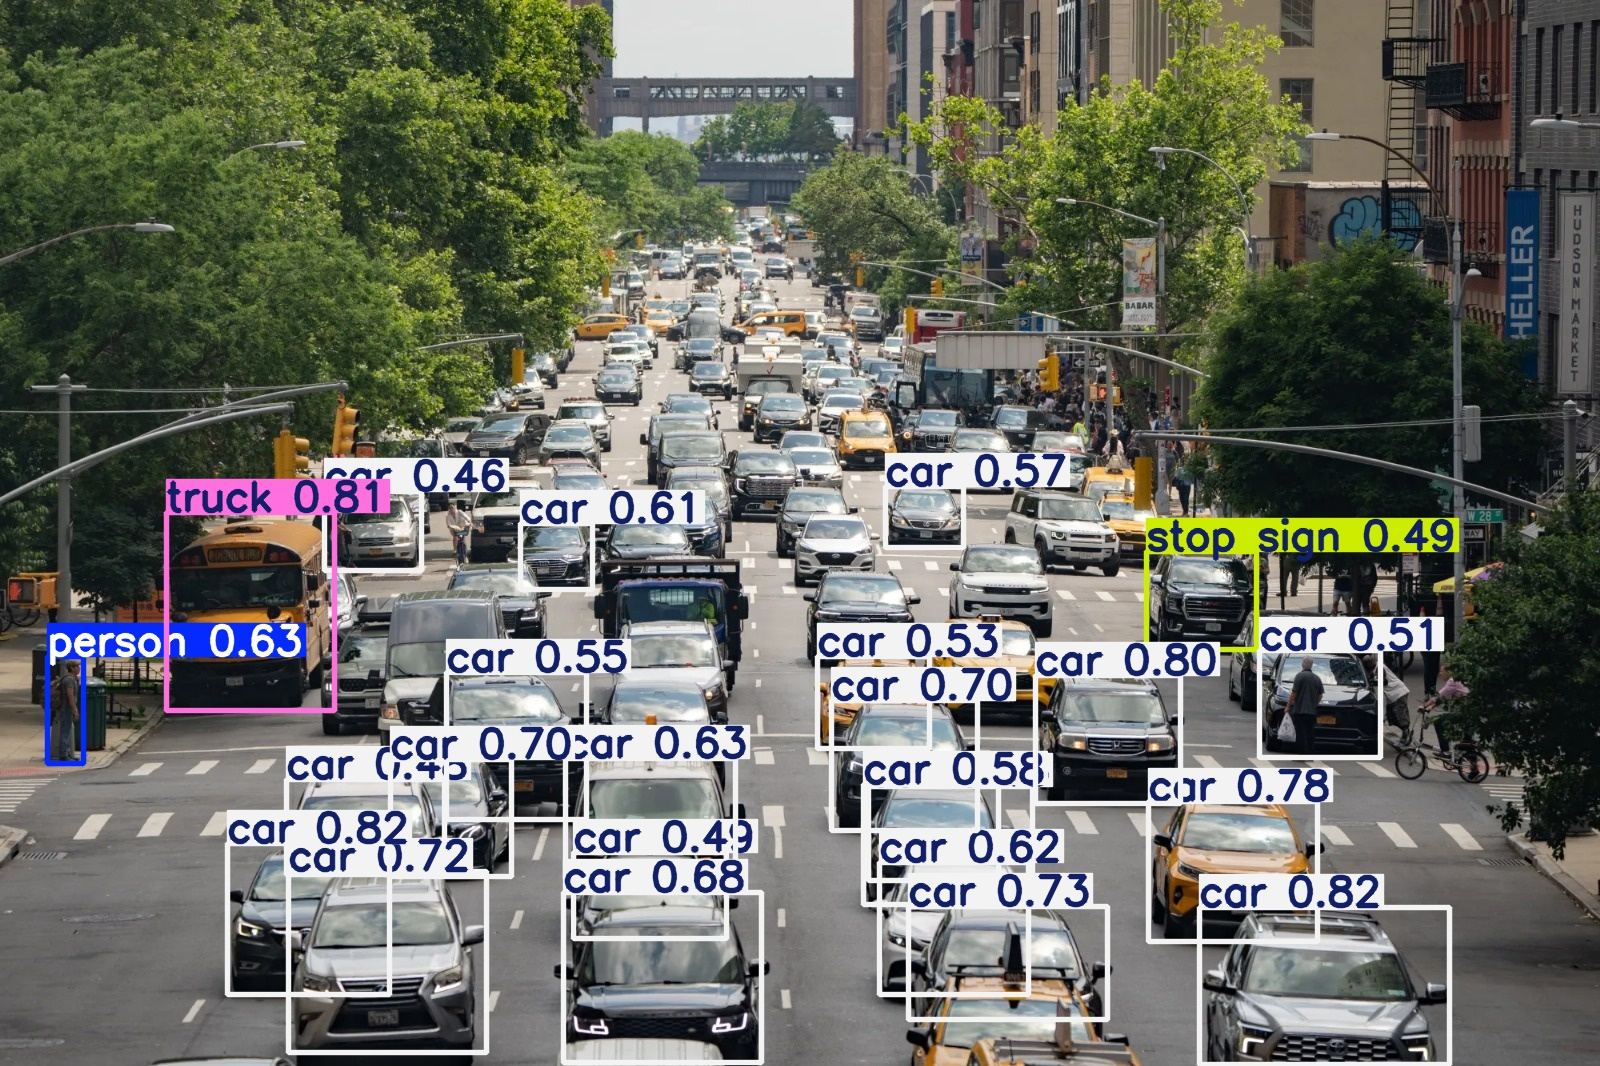


image 1/1 /home/jovyan/tests/test_images/1.jpg: 352x640 25 cars, 5 stop signs, 118.3ms
Speed: 2.5ms preprocess, 118.3ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /home/jovyan/tests/test_images/4.jpg: 384x640 12 cars, 1 truck, 135.1ms
Speed: 2.8ms preprocess, 135.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/jovyan/tests/test_images/6.jpg: 544x640 11 cars, 186.7ms
Speed: 4.8ms preprocess, 186.7ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /home/jovyan/tests/test_images/2.jpg: 448x640 34 cars, 1 stop sign, 160.5ms
Speed: 3.2ms preprocess, 160.5ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/5.jpg: 384x640 21 cars, 5 stop signs, 153.6ms
Speed: 2.4ms preprocess, 153.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Saved detection results to tests/results/detection_results.txt
Test Detection Results

Ima

In [42]:
def test_model_on_test_images(model, test_images, result_dir):
    """Run inference on all test images."""
    # Target classes based on the COCO traffic subset
    traffic_classes = [
        'person', 'bicycle', 'car', 'motorcycle',
        'bus', 'truck', 'traffic light', 'stop sign'
    ]
    
    # Prepare results file
    results_file = result_dir / "detection_results.txt"
    with open(results_file, 'w') as f:
        f.write(f"Test Detection Results\n")
        f.write(f"====================\n\n")
    
    # Process each test image
    for img_path in test_images:
        # Run inference explicitly on CPU
        results = model.predict(str(img_path), conf=0.45, device="cpu")
        
        # Save annotated image
        result_img = result_dir / f"{img_path.stem}_result{img_path.suffix}"
        results[0].save(str(result_img))
        
        # Get detection counts
        boxes = results[0].boxes
        detections = {cls_name: 0 for cls_name in traffic_classes}
        
        if len(boxes) > 0:
            # Count detections by class
            if hasattr(boxes, 'cls'):
                for i, cls_id in enumerate(boxes.cls.cpu().numpy()):
                    cls_id = int(cls_id)
                    if cls_id < len(traffic_classes):
                        cls_name = traffic_classes[cls_id]
                        detections[cls_name] += 1
        
        # Log results for this image
        with open(results_file, 'a') as f:
            f.write(f"Image: {img_path.name}\n")
            f.write(f"  Total detections: {len(boxes)}\n")
            f.write("  Detections by class:\n")
            for cls_name, count in detections.items():
                if count > 0:
                    f.write(f"    - {cls_name}: {count}\n")
            f.write("\n")
        
        # Display one of the results images
        if img_path == test_images[0]:  # Show first image result in notebook
            from IPython.display import Image as IPImage
            display(IPImage(str(result_img)))
    
    print(f"Saved detection results to {results_file}")
    return results_file

# Execute the function
results_file = test_model_on_test_images(model, test_images, result_dir)

# Display the results file content
with open(results_file, 'r') as f:
    print(f.read())

In [44]:
def test_model_inference_speed(model, test_images):
    """Test inference speed on test images."""
    # Check GPU availability
    if torch.cuda.is_available():
        device = "cuda"
        print("Running inference on GPU")
    else:
        device = "cpu"
        print("Running inference on CPU")
    
    # Select a sample image for testing
    sample_img_path = str(test_images[0])
    
    # Warm-up run
    print("Warming up...")
    for _ in range(3):
        model.predict(sample_img_path, device=device)
    
    # Time multiple runs
    import time
    num_runs = 5  # Reduced for notebook performance
    print(f"Running {num_runs} inference passes...")
    
    start_time = time.time()
    for _ in range(num_runs):
        model.predict(sample_img_path, device=device)
    total_time = time.time() - start_time
    
    avg_time = total_time / num_runs
    
    print(f"Average inference time per image: {avg_time:.4f} seconds")
    
    # Determine reasonable threshold based on device
    if device == "cuda":
        threshold = 0.1  # GPU threshold
    else:
        threshold = 0.5  # CPU threshold
    
    if avg_time <= threshold:
        print(f"✅ Inference speed is good ({avg_time:.4f}s < {threshold:.4f}s)")
    else:
        print(f"⚠️ Inference is slower than ideal ({avg_time:.4f}s > {threshold:.4f}s)")
    return avg_time

# Execute the function
inference_time = test_model_inference_speed(model, test_images)

Running inference on CPU
Warming up...

image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 177.1ms
Speed: 10.8ms preprocess, 177.1ms inference, 2.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 151.3ms
Speed: 4.1ms preprocess, 151.3ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 152.6ms
Speed: 3.7ms preprocess, 152.6ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
Running 5 inference passes...

image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 142.4ms
Speed: 3.6ms preprocess, 142.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 156.4m


image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 133.7ms
Speed: 3.3ms preprocess, 133.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/1.jpg: 352x640 35 cars, 7 stop signs, 108.9ms
Speed: 2.5ms preprocess, 108.9ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /home/jovyan/tests/test_images/4.jpg: 384x640 18 cars, 1 truck, 2 stop signs, 127.7ms
Speed: 2.7ms preprocess, 127.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/jovyan/tests/test_images/6.jpg: 544x640 11 cars, 1 stop sign, 175.0ms
Speed: 4.2ms preprocess, 175.0ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /home/jovyan/tests/test_images/2.jpg: 448x640 51 cars, 3 stop signs, 144.4ms
Speed: 3.1ms preprocess, 144.4ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/

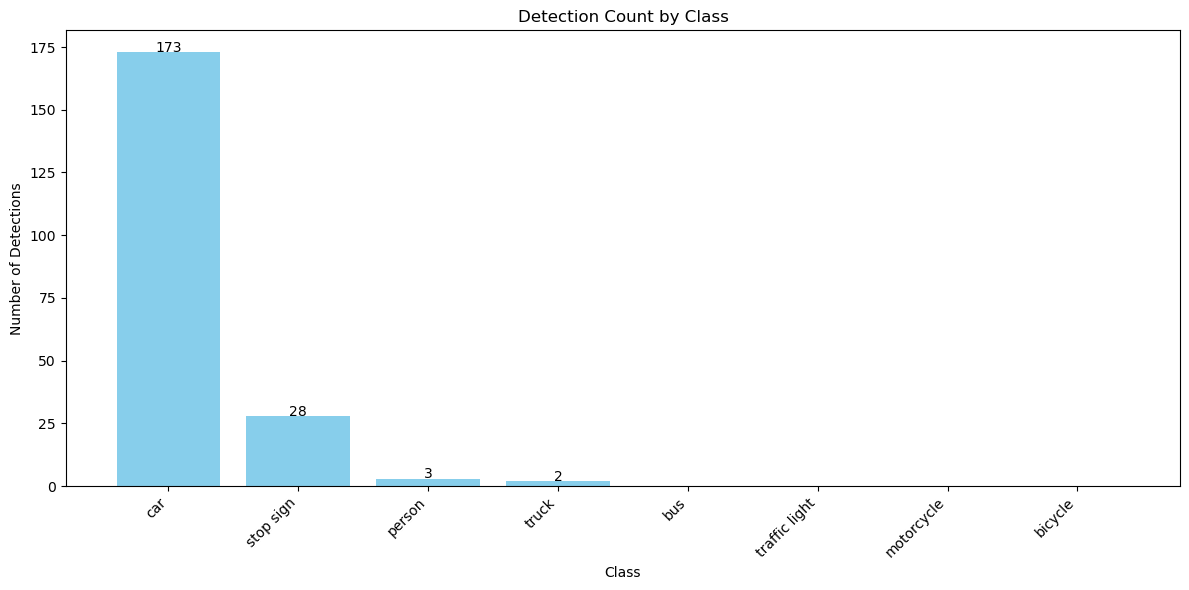

Detection Class Distribution:
Total detections: 206

Detections by class:
  - car: 173 (84.0%)
  - stop sign: 28 (13.6%)
  - person: 3 (1.5%)
  - truck: 2 (1.0%)


In [45]:
def test_class_distribution(model, test_images, result_dir):
    """Test class distribution in test images."""
    traffic_classes = [
        'person', 'bicycle', 'car', 'motorcycle',
        'bus', 'truck', 'traffic light', 'stop sign'
    ]
    
    class_counts = {cls_name: 0 for cls_name in traffic_classes}
    total_detections = 0
    
    for img_path in test_images:
        # Explicitly use CPU
        results = model.predict(str(img_path), conf=0.25, device="cpu")
        boxes = results[0].boxes
        
        if len(boxes) > 0 and hasattr(boxes, 'cls'):
            # Count detections by class
            for cls_id in boxes.cls.cpu().numpy():
                cls_id = int(cls_id)
                if cls_id < len(traffic_classes):
                    cls_name = traffic_classes[cls_id]
                    class_counts[cls_name] += 1
                    total_detections += 1
    
    # Skip if no detections
    if total_detections == 0:
        print("No detections found in test images")
        return
    
    # Create bar chart of class distribution
    plt.figure(figsize=(12, 6))
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    # Sort by count for better visualization
    sorted_indices = np.argsort(counts)[::-1]
    sorted_classes = [classes[i] for i in sorted_indices]
    sorted_counts = [counts[i] for i in sorted_indices]
    
    bars = plt.bar(sorted_classes, sorted_counts, color='skyblue')
    plt.title('Detection Count by Class')
    plt.xlabel('Class')
    plt.ylabel('Number of Detections')
    plt.xticks(rotation=45, ha='right')
    
    # Add count labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2.,
                height + 0.1,
                str(int(height)),
                ha='center'
            )
    
    plt.tight_layout()
    plt.savefig(result_dir / "class_distribution.png")
    plt.show()  # Display in notebook
    
    # Log class distribution
    class_dist_file = result_dir / "class_distribution.txt"
    with open(class_dist_file, 'w') as f:
        f.write(f"Detection Class Distribution\n")
        f.write(f"==========================\n\n")
        f.write(f"Total detections: {total_detections}\n\n")
        f.write("Detections by class:\n")
        
        # Sort by count for the text report
        for cls_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
            if count > 0:
                percentage = (count / total_detections) * 100
                f.write(f"  - {cls_name}: {count} ({percentage:.1f}%)\n")
    
    # Print class distribution
    print(f"Detection Class Distribution:")
    print(f"Total detections: {total_detections}\n")
    print("Detections by class:")
    for cls_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            percentage = (count / total_detections) * 100
            print(f"  - {cls_name}: {count} ({percentage:.1f}%)")
    
    return class_dist_file

# Execute the function
class_dist_file = test_class_distribution(model, test_images, result_dir)


image 1/1 /home/jovyan/tests/test_images/3.jpg: 448x640 3 persons, 31 cars, 1 truck, 2 stop signs, 150.0ms
Speed: 3.4ms preprocess, 150.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/1.jpg: 352x640 35 cars, 7 stop signs, 121.9ms
Speed: 2.9ms preprocess, 121.9ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /home/jovyan/tests/test_images/4.jpg: 384x640 18 cars, 1 truck, 2 stop signs, 128.2ms
Speed: 2.7ms preprocess, 128.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /home/jovyan/tests/test_images/6.jpg: 544x640 11 cars, 1 stop sign, 175.7ms
Speed: 4.5ms preprocess, 175.7ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)

image 1/1 /home/jovyan/tests/test_images/2.jpg: 448x640 51 cars, 3 stop signs, 145.0ms
Speed: 5.0ms preprocess, 145.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /home/jovyan/tests/test_images/

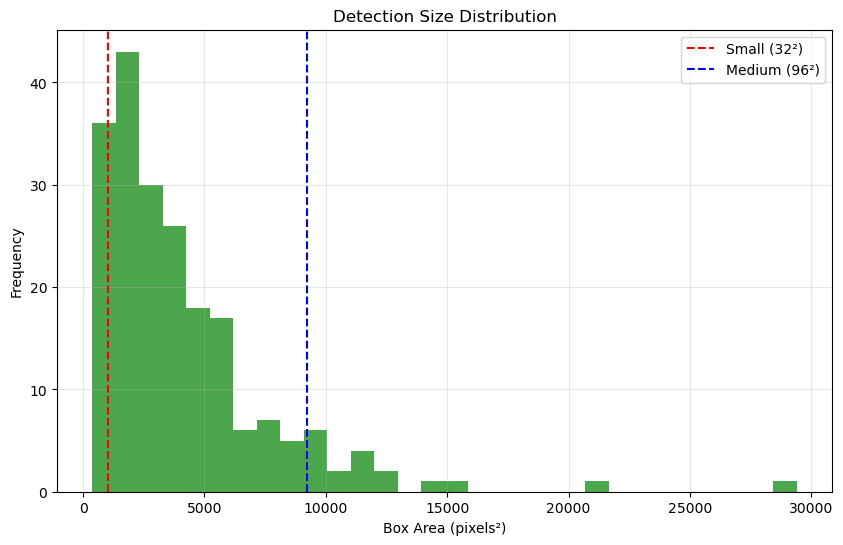

Detection Size Statistics:
Total detections: 206
Small detections (<32²): 21 (10.2%)
Medium detections (32²-96²): 168 (81.6%)
Large detections (>96²): 17 (8.3%)

Size statistics (normalized to 640x640):
  Mean area: 4052.9 pixels²
  Median area: 3101.0 pixels²
  Min area: 376.5 pixels²
  Max area: 29406.4 pixels²


In [46]:
def test_detection_size_distribution(model, test_images, result_dir):
    """Test detection box size distribution."""
    small_area = 0  # < 32²
    medium_area = 0  # 32² - 96²
    large_area = 0  # > 96²
    
    all_areas = []
    
    for img_path in test_images:
        # Get original image dimensions
        with Image.open(img_path) as img:
            img_width, img_height = img.size
        
        # Explicitly use CPU
        results = model.predict(str(img_path), conf=0.25, device="cpu")
        boxes = results[0].boxes
        
        if len(boxes) > 0 and hasattr(boxes, 'xyxy'):
            # Calculate areas for each detection
            for box in boxes.xyxy.cpu().numpy():
                x1, y1, x2, y2 = box
                width = (x2 - x1)
                height = (y2 - y1)
                
                # Calculate area in relative terms (as if image was 640x640)
                rel_width = width / img_width * 640
                rel_height = height / img_height * 640
                rel_area = rel_width * rel_height
                
                all_areas.append(rel_area)
                
                # Categorize by size
                if rel_area < 32*32:
                    small_area += 1
                elif rel_area < 96*96:
                    medium_area += 1
                else:
                    large_area += 1
    
    # Skip if no detections
    if not all_areas:
        print("No detections found in test images")
        return
    
    # Create histogram of detection areas
    plt.figure(figsize=(10, 6))
    plt.hist(all_areas, bins=30, alpha=0.7, color='green')
    plt.title('Detection Size Distribution')
    plt.xlabel('Box Area (pixels²)')
    plt.ylabel('Frequency')
    plt.axvline(x=32*32, color='r', linestyle='--', label='Small (32²)')
    plt.axvline(x=96*96, color='b', linestyle='--', label='Medium (96²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Use log scale if range is large
    if max(all_areas) / (min(all_areas) + 1) > 100:
        plt.xscale('log')
    
    plt.savefig(result_dir / "size_distribution.png")
    plt.show()  # Display in notebook
    
    # Log size statistics
    total = small_area + medium_area + large_area
    size_stats_file = result_dir / "size_stats.txt"
    with open(size_stats_file, 'w') as f:
        f.write(f"Detection Size Statistics\n")
        f.write(f"========================\n\n")
        f.write(f"Total detections: {total}\n")
        f.write(f"Small detections (<32²): {small_area} ({small_area/total*100:.1f}%)\n")
        f.write(f"Medium detections (32²-96²): {medium_area} ({medium_area/total*100:.1f}%)\n")
        f.write(f"Large detections (>96²): {large_area} ({large_area/total*100:.1f}%)\n\n")
        
        f.write("Size statistics (normalized to 640x640):\n")
        f.write(f"  Mean area: {np.mean(all_areas):.1f} pixels²\n")
        f.write(f"  Median area: {np.median(all_areas):.1f} pixels²\n")
        f.write(f"  Min area: {np.min(all_areas):.1f} pixels²\n")
        f.write(f"  Max area: {np.max(all_areas):.1f} pixels²\n")
    
    # Print size statistics
    print(f"Detection Size Statistics:")
    print(f"Total detections: {total}")
    print(f"Small detections (<32²): {small_area} ({small_area/total*100:.1f}%)")
    print(f"Medium detections (32²-96²): {medium_area} ({medium_area/total*100:.1f}%)")
    print(f"Large detections (>96²): {large_area} ({large_area/total*100:.1f}%)")
    print()
    print("Size statistics (normalized to 640x640):")
    print(f"  Mean area: {np.mean(all_areas):.1f} pixels²")
    print(f"  Median area: {np.median(all_areas):.1f} pixels²")
    print(f"  Min area: {np.min(all_areas):.1f} pixels²")
    print(f"  Max area: {np.max(all_areas):.1f} pixels²")
    
    return size_stats_file

# Execute the function
size_stats_file = test_detection_size_distribution(model, test_images, result_dir)

In [41]:
def display_summary(result_dir):
    """Display a summary of all test results."""
    result_dir = Path(result_dir)
    print("=" * 50)
    print("TEST SUMMARY")
    print("=" * 50)
    
    print("\n1. Model loaded successfully.")
    
    # Detection results
    if (result_dir / "detection_results.txt").exists():
        with open(result_dir / "detection_results.txt", 'r') as f:
            lines = f.readlines()
            image_count = sum(1 for line in lines if line.strip().startswith("Image:"))
            print(f"\n2. Successfully ran inference on {image_count} test images.")
            print(f"   Detection results saved to {result_dir}/detection_results.txt")
    
    # Confidence stats
    if (result_dir / "confidence_stats.txt").exists():
        with open(result_dir / "confidence_stats.txt", 'r') as f:
            for line in f:
                if "Mean confidence:" in line:
                    mean_conf = line.strip().split(": ")[1]
                    print(f"\n3. Mean detection confidence: {mean_conf}")
                    break
        print(f"   Confidence distribution saved to {result_dir}/confidence_histogram.png")
    
    # Class distribution
    if (result_dir / "class_distribution.txt").exists():
        with open(result_dir / "class_distribution.txt", 'r') as f:
            for line in f:
                if "Total detections:" in line:
                    total_detections = line.strip().split(": ")[1]
                    print(f"\n4. Total detections: {total_detections}")
                    break
        print(f"   Class distribution saved to {result_dir}/class_distribution.png")
    
    # Size stats
    if (result_dir / "size_stats.txt").exists():
        sizes = {"Small": 0, "Medium": 0, "Large": 0}
        with open(result_dir / "size_stats.txt", 'r') as f:
            for line in f:
                for size in sizes:
                    if f"{size} detections" in line:
                        sizes[size] = line.strip()
                        break
        
        print("\n5. Detection sizes:")
        for size, count in sizes.items():
            if count:
                print(f"   - {count}")
        print(f"   Size distribution saved to {result_dir}/size_distribution.png")
    
    print("\n" + "=" * 50)
    print(f"All results saved to {result_dir}")
    print("=" * 50)

# Show summary
display_summary(result_dir)

TEST SUMMARY

1. Model loaded successfully.

2. Successfully ran inference on 6 test images.
   Detection results saved to tests/results/detection_results.txt

3. Mean detection confidence: 0.1328
   Confidence distribution saved to tests/results/confidence_histogram.png

4. Total detections: 206
   Class distribution saved to tests/results/class_distribution.png

5. Detection sizes:
   - Small detections (<32²): 21 (10.2%)
   - Medium detections (32²-96²): 168 (81.6%)
   - Large detections (>96²): 17 (8.3%)
   Size distribution saved to tests/results/size_distribution.png

All results saved to tests/results


In [48]:
# runs in jupyter container on node-eval-offline
!pytest --verbose --tb=no tests/offline_test.py

============================= test session starts ==============================
platform linux -- Python 3.12.10, pytest-8.3.5, pluggy-1.5.0 -- /opt/conda/bin/python3.12
cachedir: .pytest_cache
rootdir: /home/jovyan
plugins: anyio-4.9.0
collected 6 items                                                              

tests/offline_test.py::test_model_download PASSED                        [ 16%]
tests/offline_test.py::test_model_loading PASSED                         [ 33%]
tests/offline_test.py::test_model_on_test_images PASSED                  [ 50%]
tests/offline_test.py::test_model_inference_speed PASSED                 [ 66%]
tests/offline_test.py::test_class_distribution PASSED                    [ 83%]
tests/offline_test.py::test_detection_size_distribution PASSED           [100%]

============================== 6 passed in 9.72s ===============================


where:

-   `--verbose` will report the result of every test, not just the ones that fail
-   `--tb=no` says not to print a traceback for every failed test
-   and `pytest` will automatically discover and run every function that starts with `test_` in this directory